In [2]:

import os
import re
from pathlib import Path
from typing import Dict, List

import joblib
import numpy as np
import pandas as pd

# Optional helper (no-op fallback if not present)
try:
    from utils.narrative_profiles_optimization_utils import set_estimator_threads
except Exception:
    def set_estimator_threads(_):  # fallback no-op
        pass

# -----------------------------
# CONFIG — edit paths if needed
# -----------------------------
SCRIPT_DIR_PATH = os.getcwd()
TRAINED_MODELS_DIR = Path(SCRIPT_DIR_PATH) / "trained_models"
MODEL_PATH = TRAINED_MODELS_DIR / "xgb_pipeline_5.10.pkl"
TRAINING_DF_PATH = TRAINED_MODELS_DIR / "xgb_pipeline_5.10_training_df.parquet"

# Targets (must match predict() column order of your pipeline)
TARGET_METRICS = [
    "emission_avg_last_five_years",
    "emission_total",
    "production_total",
    "production_cost_total",
    "technical_cost",
    "air_pollution",
    "num_jobs",
    "average_salary_jobs_added",
]


In [ ]:
# ================================================================
# Sobol Sensitivity Analysis (SALib) on EXOGENOUS inputs only
# Targets: "emission_avg_last_five_years", "emission_total"
# Assumptions:
#   - Features are split into EXOGENOUS (group_<N>, N>=46) and LEVERS (everything else)
#   - All LEVERS are fixed at 0.0 for sensitivity analysis
#   - EXOG bounds come from training distribution quantiles (default 5%..95%)
# Outputs:
#   - sobol_S1_df[target], sobol_ST_df[target], sobol_S2_df[target]  (DataFrames)
#   - ranked_df[target]  (sorted by ST descending)
#   - Printed summary of top drivers for each target
# ================================================================

import os
import re
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import joblib
import numpy as np
import pandas as pd

# ---- Optional: thread helper (no-op fallback)
try:
    from utils.narrative_profiles_optimization_utils import set_estimator_threads
except Exception:
    def set_estimator_threads(_):  # noqa: D401
        """No-op if helper not available."""
        pass

# ---- SALib for Sobol
try:
    from SALib.analyze import sobol
    from SALib.sample import saltelli
except Exception as e:
    raise RuntimeError(
        "SALib is required for Sobol analysis. Please install it via:\n\n"
        "    pip install SALib\n"
        f"\nOriginal import error: {e}"
    )

# -----------------------------
# CONFIG — adjust paths / knobs
# -----------------------------
SCRIPT_DIR_PATH = os.getcwd()
TRAINED_MODELS_DIR = Path(SCRIPT_DIR_PATH) / "trained_models"
MODEL_PATH = TRAINED_MODELS_DIR / "xgb_pipeline_5.10.pkl"
TRAINING_DF_PATH = TRAINED_MODELS_DIR / "xgb_pipeline_5.10_training_df.parquet"

# Model outputs of interest (your two targets)
TARGETS = [
    "emission_avg_last_five_years",
    "emission_total",
    "production_total",
    "production_cost_total",
    "technical_cost",
    "air_pollution",
    "num_jobs",
    "average_salary_jobs_added"
]

# Exogenous detection rule: "group_<N>" with N >= 46
EXOG_MIN_INDEX = 46
EXOG_RX = re.compile(r"^group_(\d+)(?:_|$)")

# Bounds from training distribution (use quantiles to stay in-distribution)
LOW_Q = 0.05
HIGH_Q = 0.95

# Saltelli sampling controls:
# Base sample size N -> total evals ≈ N * (2D + 2), where D = #exogenous vars
# For many exogenous variables, start small and scale up.
N_BASE = 512         # adjust as needed
CALC_SECOND_ORDER = False  # set True to include S2 (much more expensive)

# Batch prediction to avoid memory spikes
BATCH_SIZE = 4096

# Optional saving
SAVE_TABLES = False
OUT_DIR = Path(SCRIPT_DIR_PATH) / "sobol_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load model + training data
# -----------------------------
pipeline = joblib.load(MODEL_PATH)
set_estimator_threads(pipeline)

full_df = pd.read_parquet(TRAINING_DF_PATH)

# Preferred feature order from pipeline
try:
    feature_cols = list(pipeline.feature_names_in_)
except AttributeError:
    # Fallback: infer by excluding targets if your parquet contains both
    feature_cols = [c for c in full_df.columns if c not in TARGETS]

X_ref = full_df[feature_cols].copy()

# -----------------------------
# Identify EXOG vs LEVERS
# -----------------------------
def get_exogenous_cols(cols: List[str], min_idx: int = EXOG_MIN_INDEX) -> List[str]:
    out = []
    for c in cols:
        m = EXOG_RX.match(c)
        if m and int(m.group(1)) >= min_idx:
            out.append(c)
    return out

EXOG_COLS = get_exogenous_cols(feature_cols, min_idx=EXOG_MIN_INDEX)
if not EXOG_COLS:
    raise ValueError(
        f"No exogenous columns found (expected 'group_<N>' with N >= {EXOG_MIN_INDEX})."
    )

LEVER_COLS = [c for c in feature_cols if c not in EXOG_COLS]
if not LEVER_COLS:
    raise ValueError("No lever columns detected (all features classified exogenous).")

# -----------------------------
# Build SALib problem definition
# -----------------------------
# Use quantile bounds (LOW_Q..HIGH_Q) from training distribution to avoid OOD sampling
q_low = X_ref[EXOG_COLS].quantile(LOW_Q, numeric_only=True)
q_high = X_ref[EXOG_COLS].quantile(HIGH_Q, numeric_only=True)

# Edge case: if any low==high, expand a tiny epsilon so SALib won't choke
eps = 1e-9
bounds = []
for c in EXOG_COLS:
    lo = float(q_low[c])
    hi = float(q_high[c])
    if not np.isfinite(lo) or not np.isfinite(hi):
        raise ValueError(f"Non-finite bounds for {c}: [{lo}, {hi}]")
    if hi <= lo:
        hi = lo + eps
    bounds.append([lo, hi])

problem = {
    "num_vars": len(EXOG_COLS),
    "names": EXOG_COLS,
    "bounds": bounds,
}

# -----------------------------
# Sample with Saltelli
# -----------------------------
# Note: Saltelli sampling creates a structured design for Sobol indices
X_exog = saltelli.sample(
    problem,
    N_BASE,
    calc_second_order=CALC_SECOND_ORDER,
)

# -----------------------------
# Assemble full feature matrix
# -----------------------------
# We create one row per sample, with:
# - lever cols = 0.0
# - exogenous cols = X_exog (in problem order)
def assemble_features_from_exog_samples(samples: np.ndarray) -> pd.DataFrame:
    n = samples.shape[0]
    X = pd.DataFrame(0.0, index=np.arange(n), columns=feature_cols, dtype=float)
    # Fill levers (already zero)
    X.loc[:, LEVER_COLS] = 0.0
    # Fill exogenous in their respective columns
    for j, c in enumerate(EXOG_COLS):
        X.loc[:, c] = samples[:, j]
    return X

X_eval = assemble_features_from_exog_samples(X_exog)

# -----------------------------
# Predict in batches
# -----------------------------
def predict_in_batches(X: pd.DataFrame, batch_size: int = 4096) -> np.ndarray:
    out = []
    n = len(X)
    for i in range(0, n, batch_size):
        Yb = pipeline.predict(X.iloc[i:i+batch_size, :])
        Yb = np.asarray(Yb)
        if Yb.ndim == 1:
            Yb = Yb.reshape(-1, 1)
        out.append(Yb)
    return np.vstack(out)

Y_all = predict_in_batches(X_eval, batch_size=BATCH_SIZE)  # shape: (n_samples, n_outputs)

# -----------------------------
# Map model outputs to targets
# -----------------------------
# If  pipeline returns named outputs or a known order, map here.
# Default: assume positions 0 and 1 are the two requested targets (edit if needed).
pos_map = {
    "emission_avg_last_five_years": 0,
    "emission_total": 1, 
    "production_total"  :2,
    "production_cost_total": 3,
    "technical_cost": 4,
    "air_pollution": 5,
    "num_jobs": 6,
    "average_salary_jobs_added": 7
}

missing = [t for t in TARGETS if t not in pos_map]
if missing:
    raise RuntimeError(f"Position map missing targets: {missing}")

# -----------------------------
# Compute Sobol indices (per target)
# -----------------------------
sobol_S1_df: Dict[str, pd.DataFrame] = {}
sobol_ST_df: Dict[str, pd.DataFrame] = {}
sobol_S2_df: Dict[str, pd.DataFrame] = {}
ranked_df: Dict[str, pd.DataFrame] = {}

for tgt in TARGETS:
    col_idx = pos_map[tgt]
    y = Y_all[:, col_idx]  # 1D array of model outputs for this target

    Si = sobol.analyze(
        problem,
        y,
        calc_second_order=CALC_SECOND_ORDER,
        print_to_console=False,
        conf_level=0.95,
    )

    # Build tidy DataFrames
    df_S1 = pd.DataFrame({
        "parameter": EXOG_COLS,
        "S1": Si["S1"],
        "S1_conf": Si["S1_conf"],
    }).sort_values("S1", ascending=False, na_position="last").reset_index(drop=True)

    df_ST = pd.DataFrame({
        "parameter": EXOG_COLS,
        "ST": Si["ST"],
        "ST_conf": Si["ST_conf"],
    }).sort_values("ST", ascending=False, na_position="last").reset_index(drop=True)

    sobol_S1_df[tgt] = df_S1
    sobol_ST_df[tgt] = df_ST

    if CALC_SECOND_ORDER and "S2" in Si and Si["S2"] is not None:
        # S2 is a symmetric matrix with NaNs on the diagonal; convert to tidy form
        names = EXOG_COLS
        S2 = pd.DataFrame(Si["S2"], index=names, columns=names)
        S2_conf = pd.DataFrame(Si["S2_conf"], index=names, columns=names)

        pairs = []
        for i, a in enumerate(names):
            for j, b in enumerate(names):
                if j <= i:
                    continue
                pairs.append({
                    "param_i": a,
                    "param_j": b,
                    "S2": S2.loc[a, b],
                    "S2_conf": S2_conf.loc[a, b],
                })
        sobol_S2_df[tgt] = pd.DataFrame(pairs).sort_values("S2", ascending=False, na_position="last")

    # Rank parameters by Total-Order index (captures interactions)
    ranked_df[tgt] = df_ST.copy()

# -----------------------------
# Display / Save
# -----------------------------
for tgt in TARGETS:
    print(f"\n================ Sobol Results — {tgt} ================")
    print("Top drivers by Total-Order (ST):")
    print(ranked_df[tgt].head(12).to_string(index=False))

if SAVE_TABLES:
    for tgt in TARGETS:
        sobol_S1_df[tgt].to_csv(OUT_DIR / f"sobol_S1_{tgt}.csv", index=False)
        sobol_ST_df[tgt].to_csv(OUT_DIR / f"sobol_ST_{tgt}.csv", index=False)
        if CALC_SECOND_ORDER and tgt in sobol_S2_df:
            sobol_S2_df[tgt].to_csv(OUT_DIR / f"sobol_S2_{tgt}.csv", index=False)


C:\Users\nasta\AppData\Local\Temp\ipykernel_45284\3384043759.py:151: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  X_exog = saltelli.sample(
c:\Users\nasta\anaconda3\envs\ssp_metamodel_env\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))



================ Sobol Results — emission_avg_last_five_years ================
Top drivers by Total-Order (ST):
                                                     parameter       ST  ST_conf
                                          group_48_gdp_mmm_usd 0.532194 0.058844
                                 group_46_exports_enfu_pj_fuel 0.427163 0.045405
                                      group_52_population_gnrl 0.013513 0.002478
                                      group_50_elasticity_ippu 0.010567 0.001406
                                         group_57_nemomod_entc 0.009285 0.001328
                         group_59_elasticity_trde_pkm_to_gdppc 0.007186 0.000919
                         group_54_nemomod_enst_capital_cost_st 0.003096 0.000482
group_49_scalar_inen_energy_demand_other_product_manufacturing 0.002859 0.000627
                                         group_55_nemomod_entc 0.001238 0.000312
                                         group_56_nemomod_entc 0.000854 0.000

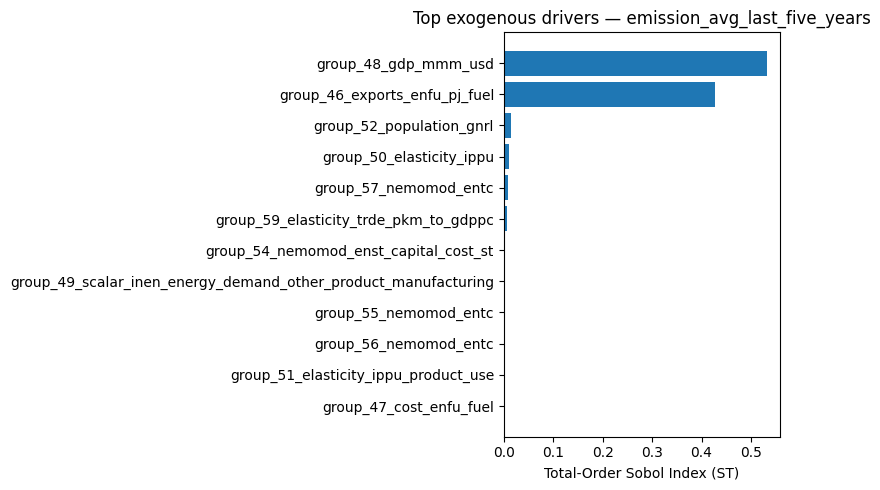

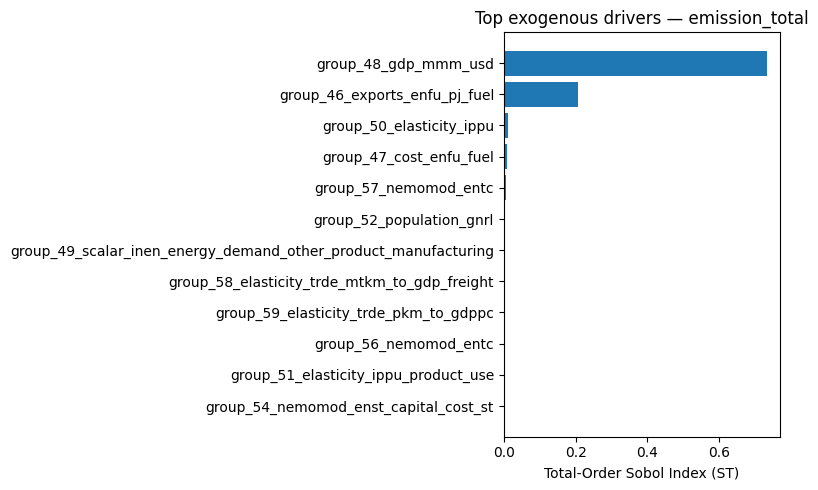

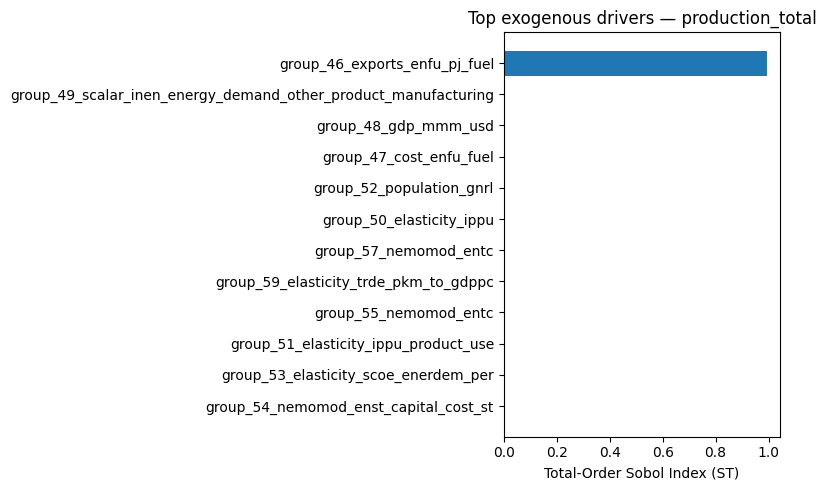

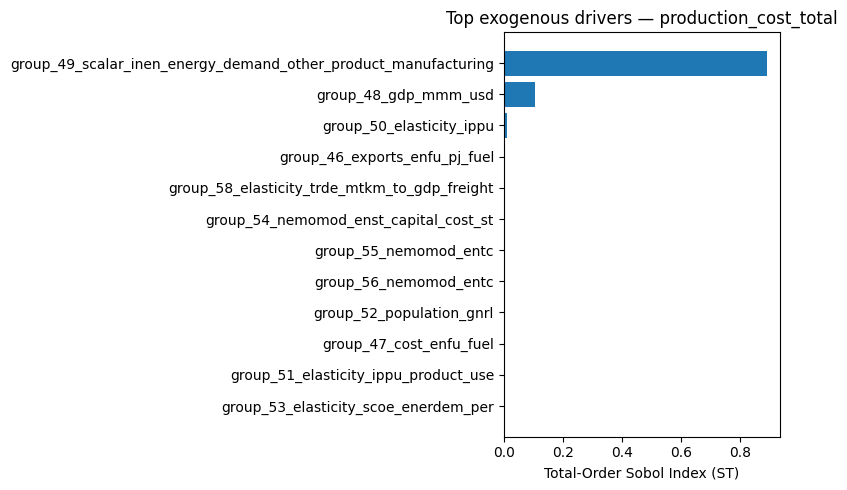

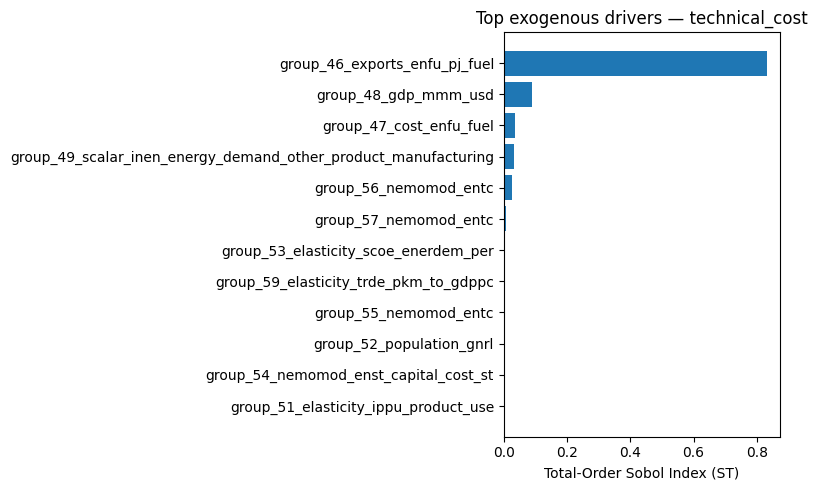

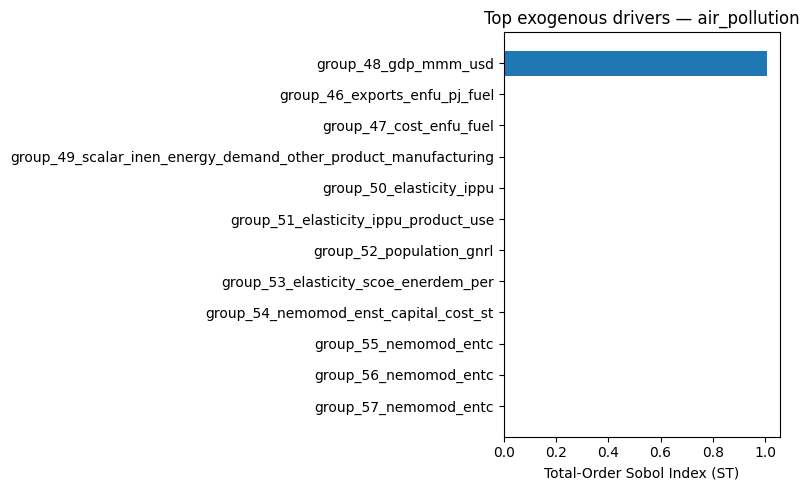

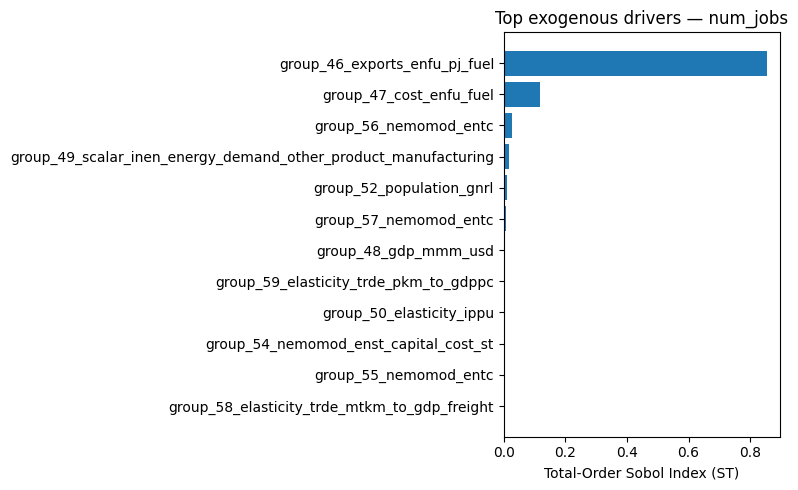

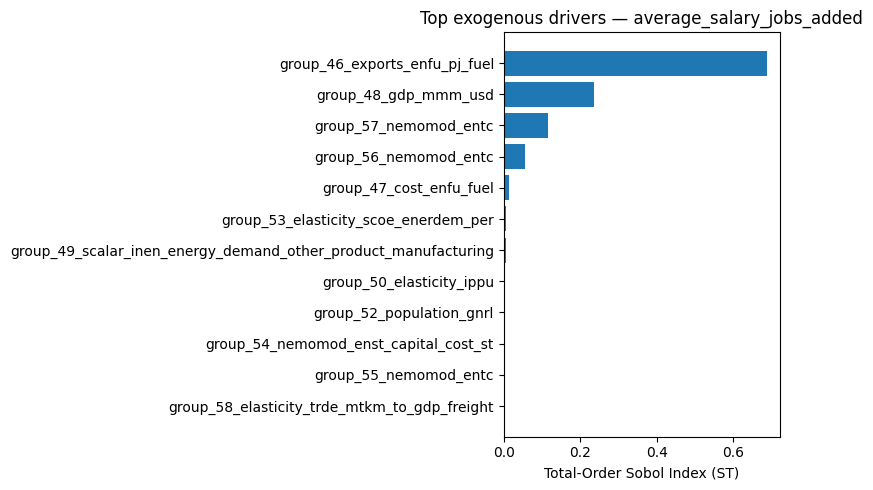

In [5]:

# Optional: quick bar plots 
import matplotlib.pyplot as plt
for tgt in TARGETS:
    sub = ranked_df[tgt].head(12)
    plt.figure(figsize=(8, 5))
    plt.barh(sub["parameter"], sub["ST"])
    plt.gca().invert_yaxis()
    plt.xlabel("Total-Order Sobol Index (ST)")
    plt.title(f"Top exogenous drivers — {tgt}")
    plt.tight_layout()
    plt.show()